### 2.1 


1. 

$$
a\cdot b = 2\times 1 + (-1)\times 4 + 3\times (-2) = 2-4-6=-8
$$

2. 

$$
AB=
\begin{bmatrix}
1&0&2\\
-1&3&1
\end{bmatrix}
\begin{bmatrix}
2&1\\
0&-1\\
3&2
\end{bmatrix}
=
\begin{bmatrix}
8&5\\
1&-2
\end{bmatrix}
$$

结果矩阵形状为 **$2\times 2$**。

3. 

$$
\|a\|_F = \sqrt{2^2+(-1)^2+3^2}=\sqrt{14}
$$

In [1]:
import numpy as np

np.random.seed(42)

X = np.random.randn(3, 4)
Y = np.ones((4, 2)) 
Z = X @ Y

print("X =")
print(X)
print("\nY =")
print(Y)
print("\nZ = X @ Y =")
print(Z)

print("\nZ 的第一行第二列元素 Z[0, 1] =", Z[0, 1])
print("Z 的第 2 行所有元素 Z[1, :] =", Z[1, :])
print("Z 的 Frobenius 范数 =", np.linalg.norm(Z, ord='fro'))

X =
[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]

Y =
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

Z = X @ Y =
[[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]

Z 的第一行第二列元素 Z[0, 1] = 2.5291682463487657
Z 的第 2 行所有元素 Z[1, :] = [1.87835721 1.87835721]
Z 的 Frobenius 范数 = 4.616873319476864


### 3.1 

设：

- 患病概率：$P(D)=0.001$
- 未患病概率：$P(\bar D)=0.999$
- 灵敏度：$P(+|D)=0.99$
- 假阳性率：$P(+|\bar D)=0.02$

根据贝叶斯公式：

$$
P(D|+) = \frac{P(+|D)P(D)}{P(+|D)P(D)+P(+|\bar D)P(\bar D)}
$$

代入得：

$$
P(D|+) = \frac{0.99\times 0.001}{0.99\times 0.001 + 0.02\times 0.999}
= \frac{0.00099}{0.02097}
\approx 0.0472
$$

所以，一个人检测结果为阳性时，他真正患病的概率约为 **4.72%**。

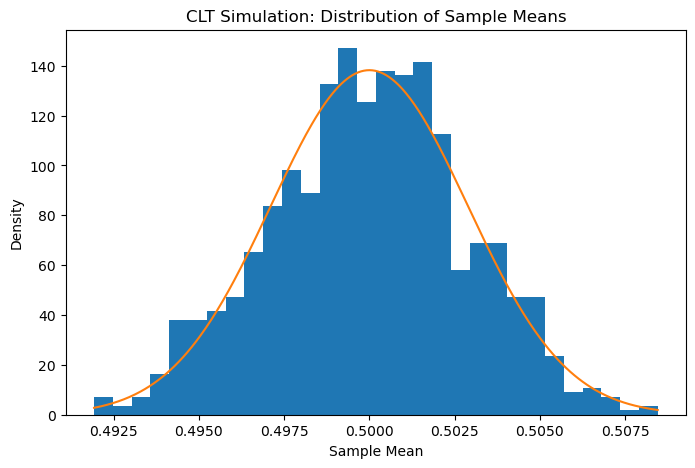

1000 个样本均值的实际均值 = 0.49999248038362676
1000 个样本均值的实际方差 = 8.275637010510707e-06
理论方差 = 8.333333333333334e-06


In [2]:
# 3.2 
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 10000
m = 1000

samples = np.random.uniform(0, 1, size=(m, n))
means = samples.mean(axis=1)

# 理论参数：U(0,1) 的均值为 0.5，方差为 1/12
mu = 0.5
sigma2 = 1 / (12 * n)
sigma = np.sqrt(sigma2)

x = np.linspace(means.min(), means.max(), 400)
pdf = (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-(x - mu) ** 2 / (2 * sigma2))

plt.figure(figsize=(8, 5))
plt.hist(means, bins=30, density=True)
plt.plot(x, pdf)
plt.title("CLT Simulation: Distribution of Sample Means")
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.show()

print("1000 个样本均值的实际均值 =", means.mean())
print("1000 个样本均值的实际方差 =", means.var())
print("理论方差 =", sigma2)

### 4.1 

给定：

$$
z=(w_1x_1+w_2x_2-y)^2,\quad x_1=2,\ x_2=1,\ y=3
$$

先记：

$$
t=w_1x_1+w_2x_2-y=2w_1+w_2-3
$$

则：

$$
z=t^2
$$

由链式法则：

$$
\frac{\partial z}{\partial w_1}=2t\cdot \frac{\partial t}{\partial w_1}
=2(2w_1+w_2-3)\cdot 2
=4(2w_1+w_2-3)
$$

$$
\frac{\partial z}{\partial w_2}=2t\cdot \frac{\partial t}{\partial w_2}
=2(2w_1+w_2-3)\cdot 1
=2(2w_1+w_2-3)
$$

当 $w_1=0.5,\ w_2=1$ 时：

$$
2w_1+w_2-3=2\times 0.5 + 1 - 3 = -1
$$

所以：

$$
\frac{\partial z}{\partial w_1}=4(-1)=-4,\qquad
\frac{\partial z}{\partial w_2}=2(-1)=-2
$$

In [3]:
# 4.2 
import torch

x = 2.0
w1 = 1.5
w2 = 0.5

# 手动前向
a = x * w1
b = a + w2
L = b ** 2

# 手动反向
dL_db = 2 * b
dL_dw2 = dL_db * 1
dL_dw1 = dL_db * x

print("手动前向结果：")
print("a =", a)
print("b =", b)
print("L =", L)

print("\n手动反向结果：")
print("dL/dw1 =", dL_dw1)
print("dL/dw2 =", dL_dw2)

# autograd 验证
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)
x_t = torch.tensor(2.0)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2
L_t.backward()

print("\n自动微分结果：")
print("dL/dw1 =", w1_t.grad.item())
print("dL/dw2 =", w2_t.grad.item())

手动前向结果：
a = 3.0
b = 3.5
L = 12.25

手动反向结果：
dL/dw1 = 14.0
dL/dw2 = 7.0

自动微分结果：
dL/dw1 = 14.0
dL/dw2 = 7.0


### 5.1 

线性回归模型：

$$
\hat y_i = wx_i + b
$$

均方误差损失：

$$
L = \frac{1}{n}\sum_{i=1}^{n}(y_i-(wx_i+b))^2
$$

对 $w$ 求偏导：

$$
\frac{\partial L}{\partial w}
=
\frac{1}{n}\sum_{i=1}^{n}2(y_i-(wx_i+b))\cdot(-x_i)
=
-\frac{2}{n}\sum_{i=1}^{n}x_i\big(y_i-(wx_i+b)\big)
$$


对 $b$ 求偏导：

$$
\frac{\partial L}{\partial b}
=
\frac{1}{n}\sum_{i=1}^{n}2(y_i-(wx_i+b))\cdot(-1)
=
-\frac{2}{n}\sum_{i=1}^{n}\big(y_i-(wx_i+b)\big)
$$

Epoch 10, train loss = 0.437650
Epoch 20, train loss = 0.292064
Epoch 30, train loss = 0.234489
Epoch 40, train loss = 0.202128
Epoch 50, train loss = 0.180541

测试集准确率 = 0.9527777777777777


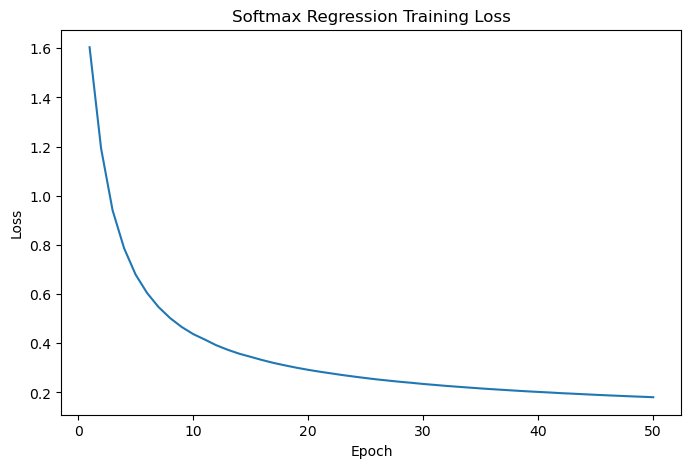

In [4]:
# 5.2 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

np.random.seed(42)

digits = load_digits()
X = digits.data.astype(np.float64) / 16.0   # 归一化到 [0, 1]
y = digits.target
num_classes = 10

def one_hot(y, num_classes):
    out = np.zeros((len(y), num_classes))
    out[np.arange(len(y)), y] = 1.0
    return out

def softmax(logits):
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    exp_scores = np.exp(shifted)
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

def cross_entropy(probs, y_onehot):
    eps = 1e-12
    return -np.mean(np.sum(y_onehot * np.log(probs + eps), axis=1))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
Y_train = one_hot(y_train, num_classes)
Y_test = one_hot(y_test, num_classes)

n_features = X_train.shape[1]
W = np.zeros((n_features, num_classes))
b = np.zeros((1, num_classes))

lr = 0.1
batch_size = 32
epochs = 50
n = X_train.shape[0]
loss_history = []

for epoch in range(epochs):
    indices = np.random.permutation(n)
    X_train_shuffled = X_train[indices]
    Y_train_shuffled = Y_train[indices]

    for start in range(0, n, batch_size):
        end = start + batch_size
        xb = X_train_shuffled[start:end]
        yb = Y_train_shuffled[start:end]

        logits = xb @ W + b
        probs = softmax(logits)

        grad_logits = (probs - yb) / len(xb)
        grad_W = xb.T @ grad_logits
        grad_b = np.sum(grad_logits, axis=0, keepdims=True)

        W -= lr * grad_W
        b -= lr * grad_b

    train_probs = softmax(X_train @ W + b)
    train_loss = cross_entropy(train_probs, Y_train)
    loss_history.append(train_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1:02d}, train loss = {train_loss:.6f}")

test_probs = softmax(X_test @ W + b)
test_pred = np.argmax(test_probs, axis=1)
test_acc = np.mean(test_pred == y_test)

print("\n测试集准确率 =", test_acc)

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_history)
plt.title("Softmax Regression Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


### 6.1 

设样本 $x_1,x_2,\dots,x_n$ 独立同分布于正态分布 $N(\mu,\sigma^2)$。

#### 1）似然函数

单个样本的概率密度为：

$$
f(x_i|\mu,\sigma^2)=\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)
$$

所以样本的似然函数为：

$$
L(\mu,\sigma^2)
=\prod_{i=1}^{n}f(x_i|\mu,\sigma^2)
=
\left(\frac{1}{\sqrt{2\pi\sigma^2}}\right)^n
\exp\left(-\frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2\right)
$$

#### 2）证明 $\hat\mu=\frac{1}{n}\sum_{i=1}^{n}x_i$

取对数似然：

$$
\ell(\mu,\sigma^2)=\ln L(\mu,\sigma^2)
=
-\frac{n}{2}\ln(2\pi)-\frac{n}{2}\ln(\sigma^2)
-\frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2
$$

对 $\mu$ 求导：

$$
\frac{\partial \ell}{\partial \mu}
=
-\frac{1}{2\sigma^2}\cdot 2\sum_{i=1}^{n}(x_i-\mu)(-1)
=
\frac{1}{\sigma^2}\sum_{i=1}^{n}(x_i-\mu)
$$

令其等于 0：

$$
\sum_{i=1}^{n}(x_i-\mu)=0
\Rightarrow
\sum_{i=1}^{n}x_i-n\mu=0
\Rightarrow
\hat\mu=\frac{1}{n}\sum_{i=1}^{n}x_i
$$

#### 3）证明 $\hat\sigma^2=\frac{1}{n}\sum_{i=1}^{n}(x_i-\hat\mu)^2$

对 $\sigma^2$ 求导：

$$
\frac{\partial \ell}{\partial \sigma^2}
=
-\frac{n}{2\sigma^2}
+\frac{1}{2(\sigma^2)^2}\sum_{i=1}^{n}(x_i-\mu)^2
$$

令其等于 0：

$$
-\frac{n}{2\sigma^2}
+\frac{1}{2(\sigma^2)^2}\sum_{i=1}^{n}(x_i-\mu)^2 = 0
$$

两边乘以 $2(\sigma^2)^2$：

$$
-n\sigma^2+\sum_{i=1}^{n}(x_i-\mu)^2=0
$$

得到：

$$
\hat\sigma^2=\frac{1}{n}\sum_{i=1}^{n}(x_i-\mu)^2
$$

再将 $\mu$ 用 $\hat\mu$ 代入，即：

$$
\hat\sigma^2=\frac{1}{n}\sum_{i=1}^{n}(x_i-\hat\mu)^2
$$

Iter 0200, loss = 0.012603
Iter 0400, loss = 0.007246
Iter 0600, loss = 0.005275
Iter 0800, loss = 0.004222
Iter 1000, loss = 0.003557

学习到的参数：
w = [1.96081617 1.82536906]
b = -0.005272389850700089
测试集准确率 = 1.0


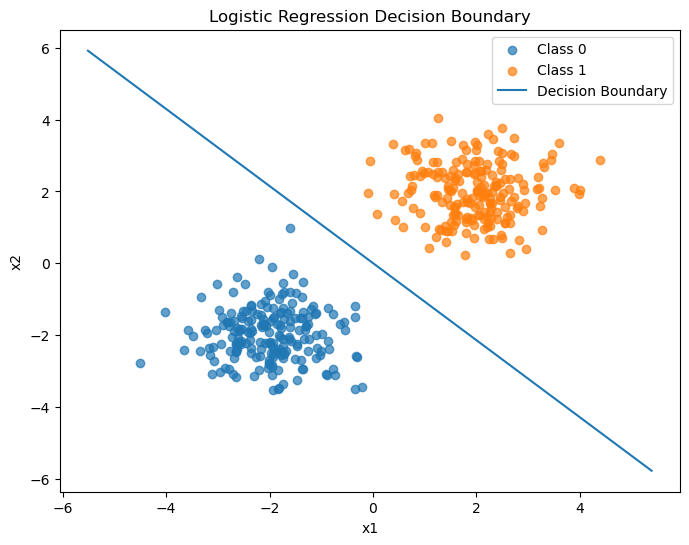

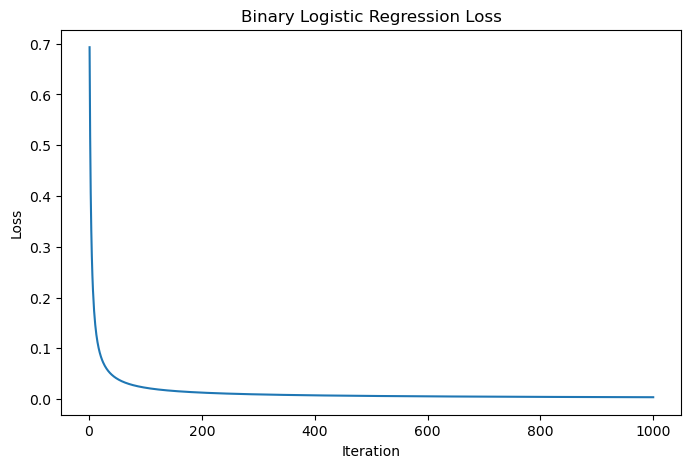

In [5]:
# 6.2 
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def make_binary_data(n_per_class=200):
    mean0 = np.array([-2.0, -2.0])
    mean1 = np.array([ 2.0,  2.0])
    cov = np.array([[0.6, 0.0],
                    [0.0, 0.6]])

    X0 = np.random.multivariate_normal(mean0, cov, size=n_per_class)
    X1 = np.random.multivariate_normal(mean1, cov, size=n_per_class)

    X = np.vstack([X0, X1])
    y = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)])
    return X, y

X_train, y_train = make_binary_data(200)
X_test, y_test = make_binary_data(50)   # 新生成 100 个样本（每类 50）

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def binary_cross_entropy(y_true, y_pred):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

w = np.zeros(X_train.shape[1])
b = 0.0

lr = 0.1
num_iters = 1000
m = len(X_train)
loss_history = []

for i in range(num_iters):
    logits = X_train @ w + b
    y_pred = sigmoid(logits)

    loss = binary_cross_entropy(y_train, y_pred)
    loss_history.append(loss)

    grad_w = (X_train.T @ (y_pred - y_train)) / m
    grad_b = np.mean(y_pred - y_train)

    w -= lr * grad_w
    b -= lr * grad_b

    if (i + 1) % 200 == 0:
        print(f"Iter {i + 1:04d}, loss = {loss:.6f}")

test_prob = sigmoid(X_test @ w + b)
test_pred = (test_prob >= 0.5).astype(int)
test_acc = np.mean(test_pred == y_test)

print("\n学习到的参数：")
print("w =", w)
print("b =", b)
print("测试集准确率 =", test_acc)

# 绘制数据点和决策边界
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], label="Class 0", alpha=0.7)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], label="Class 1", alpha=0.7)

x_vals = np.linspace(X_train[:, 0].min() - 1, X_train[:, 0].max() + 1, 200)
if abs(w[1]) > 1e-12:
    y_vals = -(w[0] * x_vals + b) / w[1]
    plt.plot(x_vals, y_vals, label="Decision Boundary")
else:
    x_boundary = -b / w[0]
    plt.axvline(x_boundary, label="Decision Boundary")

plt.title("Logistic Regression Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_iters + 1), loss_history)
plt.title("Binary Logistic Regression Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()